# **Project Name - Amazon Prime TV Shows and Movies**


Project Type - EDA

Contribution - Individual

# **Problem Statement**-

**BUSINESS PROBLEM OVERVIEW**

Amazon Prime Video offers a vast library of movies and TV shows across multiple genres, languages, and countries. As the platform continues to expand, understanding the characteristics of its content library becomes essential for making informed business decisions.

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Amazon Prime Video dataset to identify meaningful patterns and trends in the available content. The analysis focuses on understanding the distribution of movies and TV shows, genre popularity, release trends, regional content production, IMDb ratings, runtime, and audience preferences.

By analyzing these factors, the project aims to answer key business questions such as:

* Which genres are most common on Amazon Prime Video?
*   Does the platform contain more movies or TV shows?
*   How has the content library evolved over the years?
*   Which titles have the highest IMDb ratings and popularity?
*   Which countries contribute the most content?
*   Are there any relationships between runtime, ratings, and popularity?

The insights generated from this analysis can help stakeholders understand the current content portfolio, identify audience preferences, recognize content gaps, and support strategic decisions related to content acquisition, production, and regional expansion. These findings can ultimately contribute to improving user engagement and strengthening Amazon Prime Video's competitive position in the streaming industry.

**Define Your Business Objective?**

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Amazon Prime Video dataset to identify meaningful patterns and trends in the available content. The analysis focuses on understanding the distribution of movies and TV shows, genre popularity, release trends, regional content production, IMDb ratings, runtime, and audience preferences.


# **Let's Begin !**

# **1. Know Your Data**

Import Libraries:

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

os.listdir('/content/drive/MyDrive/AmazonPrimeProject')

['credits.csv',
 'titles.csv',
 'amazon_prime_cleaned.csv',
 'Amazon prime movies & tv shows.ipynb']

In [4]:
#loading files:
titles = pd.read_csv('/content/drive/MyDrive/AmazonPrimeProject/titles.csv')

In [5]:
credits = pd.read_csv('/content/drive/MyDrive/AmazonPrimeProject/credits.csv')

**Understanding Dataset-Title**


In [6]:
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [7]:
#checking size:
titles.shape

(9871, 15)

In [8]:
#checking columns
titles.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [9]:
#checking information for datatypes:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [10]:
#statistical summary
titles.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [11]:
#checking missing values:
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6487
runtime,0
genres,0
production_countries,0
seasons,8514


In [12]:
#check for duplicates:
titles.duplicated().sum()

np.int64(3)

In [13]:
#inspect duplicates in title:
titles[titles.duplicated()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
480,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
720,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN


In [14]:
#double checking the data before deleting it:
titles[titles['id'].isin(['tm89134', 'tm66674', 'tm137955'])]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
479,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
480,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
718,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
719,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN
720,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN


In [15]:
#droping duplicates
titles = titles.drop_duplicates()

In [16]:
titles.shape

(9868, 15)

In [17]:
#rechecking for any duplicates:
titles.duplicated().sum()

np.int64(0)

**Understanding Dataset-Credits**

In [18]:
credits.head()


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [19]:
#checking rows and columns
credits.shape

(124235, 5)

In [20]:
#checking information for datatypes:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [21]:
#checking missing values:
credits.isnull().sum()

,0
person_id,0
id,0
name,0
character,16287
role,0


In [22]:
#checking for duplicates:
credits.duplicated().sum()

np.int64(56)

In [23]:
#inspecting duplicates:
credits[credits.duplicated()].head(10)

,person_id,id,name,character,role
9156,130904,tm89134,Buck Jones,Buck Roberts,ACTOR
9157,36589,tm89134,Tim McCoy,Marshal McCall,ACTOR
9158,130905,tm89134,Raymond Hatton,Sandy,ACTOR
9159,132916,tm89134,Christine McIntyre,Alice Borden,ACTOR
9160,132381,tm89134,Dave O'Brien,Joe Martin,ACTOR
9161,138410,tm89134,Robert Frazer,Wyatt,ACTOR
9162,74813,tm89134,Charles King,Steve Dunn,ACTOR
9163,27218,tm89134,Lynton Brent,Red,ACTOR
9164,27351,tm89134,Max Waizmann,Sheriff Cox,ACTOR
9165,153737,tm89134,Gene Alsace,Henchman,ACTOR


In [24]:
# As same title id,name,character or roll donesnot indicate the actual duplicate we need to find actual duplicates:
credits[credits.duplicated(keep=False)].sort_values(['id','person_id']).head(20)

,person_id,id,name,character,role
12974,21688,tm137955,Beryl Mercer,Mom,ACTOR
13026,21688,tm137955,Beryl Mercer,Mom,ACTOR
12975,53498,tm137955,Joseph Cawthorn,Pop,ACTOR
13027,53498,tm137955,Joseph Cawthorn,Pop,ACTOR
12978,60949,tm137955,Sidney Bracey,Hopkins,ACTOR
13030,60949,tm137955,Sidney Bracey,Hopkins,ACTOR
12982,60957,tm137955,Edward LeSaint,Judge Harvey E. Blake,ACTOR
13034,60957,tm137955,Edward LeSaint,Judge Harvey E. Blake,ACTOR
12972,60996,tm137955,Randolph Scott,Dr. Robert Morley,ACTOR
13024,60996,tm137955,Randolph Scott,Dr. Robert Morley,ACTOR


In [25]:
#droping actual duplicates in credits:
credits = credits.drop_duplicates()

In [26]:
#rechecking duplicates in credits:
credits.duplicated().sum()

np.int64(0)

In [27]:
credits.shape

(124179, 5)

# **Data Cleaning**


In [28]:
#finding missing values - titles:
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6484
runtime,0
genres,0
production_countries,0
seasons,8511


In [29]:
#As we have lot of data to clean lets start with:
# 1.description:
titles['description'] = titles['description'].fillna('No description available')

In [30]:
# 2.Age_certification:
titles['age_certification'] = titles['age_certification'].fillna('Unknown')

In [31]:
# 3.seasons:
titles['seasons'] = titles['seasons'].fillna(0)
#convert it to integer as season is numeric:
titles['seasons'] = titles['seasons'].astype(int)

In [32]:
#reverify missing values:
titles.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,0


In [33]:
#finding missing values - credits:
credits.isnull().sum()

,0
person_id,0
id,0
name,0
character,16277
role,0


In [34]:
#here only character is having 16287 missing values so clean it:
credits['character'] = credits['character'].fillna('Not Applicable')

In [35]:
#reverify missing values in credits:
credits.isnull().sum()

,0
person_id,0
id,0
name,0
character,0
role,0


# **Data Integration**

In [36]:
#after cleaning the data we need to merge both datasets:
amazon_prime = titles.merge(credits, on='id', how='left')

In [37]:
amazon_prime.shape

(125186, 19)

In [38]:
amazon_prime.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


In [39]:
#check info after merge:
amazon_prime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125186 entries, 0 to 125185
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    125186 non-null  object 
 1   title                 125186 non-null  object 
 2   type                  125186 non-null  object 
 3   description           125186 non-null  object 
 4   release_year          125186 non-null  int64  
 5   age_certification     125186 non-null  object 
 6   runtime               125186 non-null  int64  
 7   genres                125186 non-null  object 
 8   production_countries  125186 non-null  object 
 9   seasons               125186 non-null  int64  
 10  imdb_id               119810 non-null  object 
 11  imdb_score            118819 non-null  float64
 12  imdb_votes            118789 non-null  float64
 13  tmdb_popularity       124632 non-null  float64
 14  tmdb_score            114191 non-null  float64
 15  

In [40]:
#checking missing values:
amazon_prime.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,0


In [41]:
#checking duplicates:
amazon_prime.duplicated().sum()

np.int64(0)

In [42]:
#view duplicate rows:
duplicates = amazon_prime[amazon_prime.duplicated(keep=False)]
duplicates.head(10)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role


In [43]:
#first 20 duplicates
amazon_prime[amazon_prime.duplicated()].head(20)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role


In [44]:
#droping duplicates:
amazon_prime = amazon_prime.drop_duplicates()

In [45]:
#rechecking duplicates:
amazon_prime.duplicated().sum()


np.int64(0)

In [46]:
#rechecking shape:
amazon_prime.shape

(125186, 19)

In [47]:
#saving the cleaned data into csv file:
amazon_prime.to_csv("amazon_prime_cleaned.csv", index=False)

In [48]:
#save it to drive:
amazon_prime.to_csv(
    "/content/drive/MyDrive/AmazonPrimeProject/amazon_prime_cleaned.csv",
    index=False
)

# **Feature Engineering**

Feature engineering is the process of creating new meaningful features from existing data to improve analysis and extract deeper insights.

In this project, after cleaning and integrating the Amazon Prime Video datasets, new features were created to make the dataset more suitable for exploratory data analysis. These additional features help identify patterns related to content trends, duration, release periods, and geographical distribution.

The following features were engineered:

1. Release Decade

The original dataset contains individual release years, which can make trend analysis difficult. A new feature called release_decade was created by grouping release years into decades (for example, 1990s, 2000s, 2010s).

This helps analyze how Amazon Prime Video's content library has evolved over different time periods.

2. Runtime Category

The runtime column contains the duration of movies and shows in minutes. This was transformed into categories such as short, medium, and long duration content.

This feature helps understand the distribution of content length available on the platform.

3. Content Age

A new feature was created to calculate the age of each title based on its release year.

This helps identify whether Amazon Prime's catalog mainly consists of newer releases or older classic content.

4. Number of Genres

The genres column contains multiple genres stored as a list. A new feature was created to count the number of genres associated with each title.

This helps analyze the diversity of content categories.

5. Number of Production Countries

The production countries column was transformed to calculate the number of countries involved in producing each title.

This helps understand the global diversity of Amazon Prime Video's content.

Feature engineering improves the quality of analysis by converting raw data into meaningful variables that can reveal hidden patterns and support better insights during exploratory data analysis.

**1. Release Decade:**

A new feature called release_decade was created by transforming the release year into decade-based groups. Instead of analyzing individual years, titles were grouped into decades to identify long-term content trends more effectively.


In [49]:
# Release Decade-code:
amazon_prime['release_decade'] = (amazon_prime['release_year'] // 10) * 10

In [50]:
#check results of release decade:
amazon_prime[['release_year', 'release_decade']].head(10)

,release_year,release_decade
0,1934,1930
1,1934,1930
2,1934,1930
3,1926,1920
4,1926,1920
5,1926,1920
6,1926,1920
7,1926,1920
8,1926,1920
9,1926,1920


In [51]:
#check for new columns:
amazon_prime.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role',
       'release_decade'],
      dtype='object')

**2. Runtime Category**

The original dataset contains runtime values in minutes. To make runtime analysis easier, a new feature called runtime_category was created by converting numerical runtime values into three groups:

*   Short: Content with runtime less than 60 minutes
*   Medium: Content with runtime between 60 and 120 minutes
*   Long: Content with runtime greater than 120 minutes

This transformation helps analyze the distribution of content duration and identify whether Amazon Prime Video's catalog mainly consists of short, medium, or long-duration content.

In [52]:
#checking runtime value:
amazon_prime['runtime'].describe()

,runtime
count,125186.000000
mean,95.348018
std,30.393953
min,1.000000
25%,83.000000
50%,93.000000
75%,109.000000
max,549.000000


In [53]:
#creating feature for runtime category:
amazon_prime['runtime_category'] = pd.cut(
    amazon_prime['runtime'],
    bins=[0, 60, 120, float('inf')],
    labels=['Short', 'Medium', 'Long']
)

In [54]:
#check runtime head:
amazon_prime[['runtime', 'runtime_category']].head(10)

,runtime,runtime_category
0,19,Short
1,19,Short
2,19,Short
3,78,Medium
4,78,Medium
5,78,Medium
6,78,Medium
7,78,Medium
8,78,Medium
9,78,Medium


In [55]:
#checking distribution:
amazon_prime['runtime_category'].value_counts()

,count
runtime_category,
Medium,92152
Long,18718
Short,14316


**3. Content Age**

Content Age Feature

A new feature called content_age was created by calculating the difference between the current year (2026) and the release year of each title.

This feature represents how old each movie or show is and helps analyze whether Amazon Prime Video's content library consists mainly of recent releases or older titles.

For example:

*   A title released in 2020 has a content age of 6 years.
*   A title released in 1934 has a content age of 92 years.





In [56]:
#creating feature for content age:
amazon_prime['content_age'] = 2026 - amazon_prime['release_year']

In [57]:
#checking content age head:
amazon_prime[['release_year', 'content_age']].head(10)

,release_year,content_age
0,1934,92
1,1934,92
2,1934,92
3,1926,100
4,1926,100
5,1926,100
6,1926,100
7,1926,100
8,1926,100
9,1926,100


**4. Number of Genres**

A new feature called num_genres was created by counting the number of genres associated with each title in the genres column. Since a movie or TV show can belong to multiple genres, this feature measures the diversity of genres for each title.

It helps analyze whether Amazon Prime Video's content is primarily focused on a single genre or spans multiple genres, providing insights into the variety of content available on the platform.

In [58]:
#checking datatype:
type(amazon_prime['genres'][0])

str

In [ ]:
# Convert the string representation of genres into Python lists before counting them.
import ast

amazon_prime['genres'] = amazon_prime['genres'].apply(ast.literal_eval)

# Create feature for number of genres
amazon_prime['num_genres'] = amazon_prime['genres'].apply(len)


In [60]:
amazon_prime[['genres', 'num_genres']].head(10)

,genres,num_genres
0,"['comedy', 'family', 'animation', 'action', 'f...",64
1,"['comedy', 'family', 'animation', 'action', 'f...",64
2,"['comedy', 'family', 'animation', 'action', 'f...",64
3,"['action', 'drama', 'war', 'western', 'comedy'...",59
4,"['action', 'drama', 'war', 'western', 'comedy'...",59
5,"['action', 'drama', 'war', 'western', 'comedy'...",59
6,"['action', 'drama', 'war', 'western', 'comedy'...",59
7,"['action', 'drama', 'war', 'western', 'comedy'...",59
8,"['action', 'drama', 'war', 'western', 'comedy'...",59
9,"['action', 'drama', 'war', 'western', 'comedy'...",59


**5. Number of Production countries**

A new feature called num_production_countries was created by counting the number of countries listed in the production_countries column for each title. This feature indicates whether a title was produced by a single country or through collaboration between multiple countries.

It helps evaluate the geographical diversity of Amazon Prime Video's content library and identify the extent of international co-productions available on the platform.

In [61]:
#checking datatype:
type(amazon_prime['production_countries'][0])

str

In [62]:
amazon_prime['production_countries'][0]

"['US']"

In [63]:
#need to convert string into list for feature creation:
import ast

amazon_prime['production_countries'] = amazon_prime['production_countries'].apply(ast.literal_eval)


In [64]:
#reverify datatype:
type(amazon_prime['production_countries'][0])

list

In [65]:
#create feature:
amazon_prime['num_production_countries'] = amazon_prime['production_countries'].apply(len)

In [66]:
amazon_prime[['num_production_countries', 'production_countries']].head(10)

,num_production_countries,production_countries
0,1,[US]
1,1,[US]
2,1,[US]
3,1,[US]
4,1,[US]
5,1,[US]
6,1,[US]
7,1,[US]
8,1,[US]
9,1,[US]


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is the process of examining and visualizing data to understand its characteristics, identify patterns, detect anomalies, and discover meaningful relationships between variables.

The objective of this analysis is to gain insights into Amazon Prime Video's content library by exploring the distribution of movies and TV shows, release trends, runtime patterns, ratings, genres, production countries, and other key attributes.

The analysis is divided into three sections:

Univariate Analysis – Analysis of individual variables.
Bivariate Analysis – Analysis of relationships between two variables.
Multivariate Analysis – Analysis of relationships among multiple variables.

The insights generated from EDA will help identify trends and support data-driven business recommendations.

## **Step1: Prepare EDA Dataset**

Since the credits dataset contains multiple records for the same title due to multiple actors and crew members, duplicate title entries were removed based on the unique title ID. The resulting dataset contains one row per Amazon Prime title and is used for accurate exploratory data analysis.


In [67]:
#creating eda_df
#Create a dataset with one row per movie/show
eda_df = amazon_prime.drop_duplicates(subset='id')
# Check shape
eda_df.shape

(9868, 24)

In [68]:
#checking first few rows:
eda_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,...,tmdb_score,person_id,name,character,role,release_decade,runtime_category,content_age,num_genres,num_production_countries
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",[US],26,...,7.6,59401.0,Joe Besser,Joe,ACTOR,1930,Short,92,64,1
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",[US],0,...,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR,1920,Medium,100,59,1
27,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Unknown,171,"['romance', 'war', 'drama']",[US],0,...,7.8,29993.0,Myrna Loy,Milly Stephenson,ACTOR,1940,Long,80,27,1
58,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Unknown,92,"['comedy', 'drama', 'romance']",[US],0,...,7.4,25018.0,Cary Grant,Walter Burns,ACTOR,1940,Medium,86,30,1
94,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Unknown,94,"['thriller', 'drama', 'romance']",[US],0,...,7.6,14701.0,Humphrey Bogart,Dixon 'Dix' Steele,ACTOR,1950,Medium,76,32,1


In [69]:
# Removing credit-related columns because current EDA focuses on title-level analysis

eda_df = eda_df.drop(
    columns=[
        'person_id',
        'name',
        'character',
        'role'
    ]
)



In [70]:
# Checking remaining columns
eda_df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'release_decade', 'runtime_category', 'content_age',
       'num_genres', 'num_production_countries'],
      dtype='object')

In [71]:
eda_df.shape

(9868, 20)

# **Step2: 1. Univariate Analysis**

**Analysis 1**:Content Type Distribution (Movie vs Show)

Question:What is the distribution of Movies and TV Shows available on Amazon Prime?


In [72]:
# Checking column names, data types, and missing values after preparing the final EDA dataset.
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9868 entries, 0 to 125185
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id                        9868 non-null   object  
 1   title                     9868 non-null   object  
 2   type                      9868 non-null   object  
 3   description               9868 non-null   object  
 4   release_year              9868 non-null   int64   
 5   age_certification         9868 non-null   object  
 6   runtime                   9868 non-null   int64   
 7   genres                    9868 non-null   object  
 8   production_countries      9868 non-null   object  
 9   seasons                   9868 non-null   int64   
 10  imdb_id                   9201 non-null   object  
 11  imdb_score                8847 non-null   float64 
 12  imdb_votes                8837 non-null   float64 
 13  tmdb_popularity           9321 non-null   float64 


In [73]:
# Count the number of Movies and TV Shows
eda_df['type'].value_counts()

,count
type,
MOVIE,8511
SHOW,1357


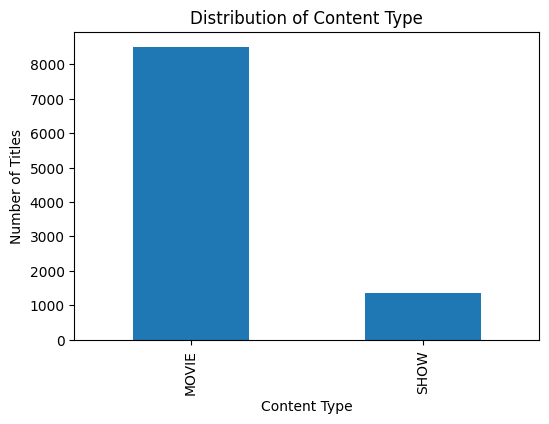

In [74]:
#Visualize Distribution:
import matplotlib.pyplot as plt

# Count Movies and TV Shows
content_type = eda_df['type'].value_counts()

# Create bar chart
plt.figure(figsize=(6,4))

content_type.plot(kind='bar')

plt.title('Distribution of Content Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()


**Bar chart:**

The content type analysis shows that Amazon Prime's catalogue is dominated by movies. Out of 9,868 total titles, 8,511 titles (86.25%) are movies, while 1,357 titles (13.75%) are TV shows. This indicates that Amazon Prime has a stronger focus on movie content compared to episodic content.

In [75]:
# Calculate percentage share of Movies and TV Shows

eda_df['type'].value_counts(normalize=True) * 100

,proportion
type,
MOVIE,86.24848
SHOW,13.75152


**Business Insights for first analysis content type distribution:**

The higher proportion of movies suggests that Amazon Prime's content strategy is primarily movie-driven. However, the presence of over 1,300 TV shows indicates that the platform also maintains a significant collection of episodic content.

**Analysis 2:** Release Year Analysis:

Question: How has Amazon Prime content production changed over time?

**Interpretation of descriptive statistics:**

**MEAN:** The average release year is approximately **2001**, indicating that the dataset contains a mixture of older and more recent titles.

**MINIMUM:** The oldest title in the dataset was released in **1912**, showing that the catalog includes classic content alongside modern titles.

**MAXIMUM:** The latest title in the dataset was released in **2022**, indicating that the dataset also includes relatively recent content.

**MEDIAN (50%):** The median release year is **2014**, meaning that 50% of the titles were released on or before 2014 and 50% were released after 2014.

**FIRST QUARTILE (25%):** 25% of the titles were released on or before **1996**.

**THIRD QUARTILE (75%):** 75% of the titles were released on or before **2018**.

**STANDARD DEVIATION:** The release years show considerable variation, indicating that the catalog includes titles from a wide range of time periods, spanning both classic and contemporary productions.


In [76]:
#descriptive statistics for release year:
eda_df['release_year'].describe()

,release_year
count,9868.000000
mean,2001.345561
std,25.792295
min,1912.000000
25%,1996.000000
50%,2014.000000
75%,2018.000000
max,2022.000000


In [77]:
#Number of titles released each year:
#count titles released each year:
release_year_count = eda_df['release_year'].value_counts().sort_index()

release_year_count.head()

,count
release_year,
1912,1
1914,2
1915,5
1916,2
1917,1


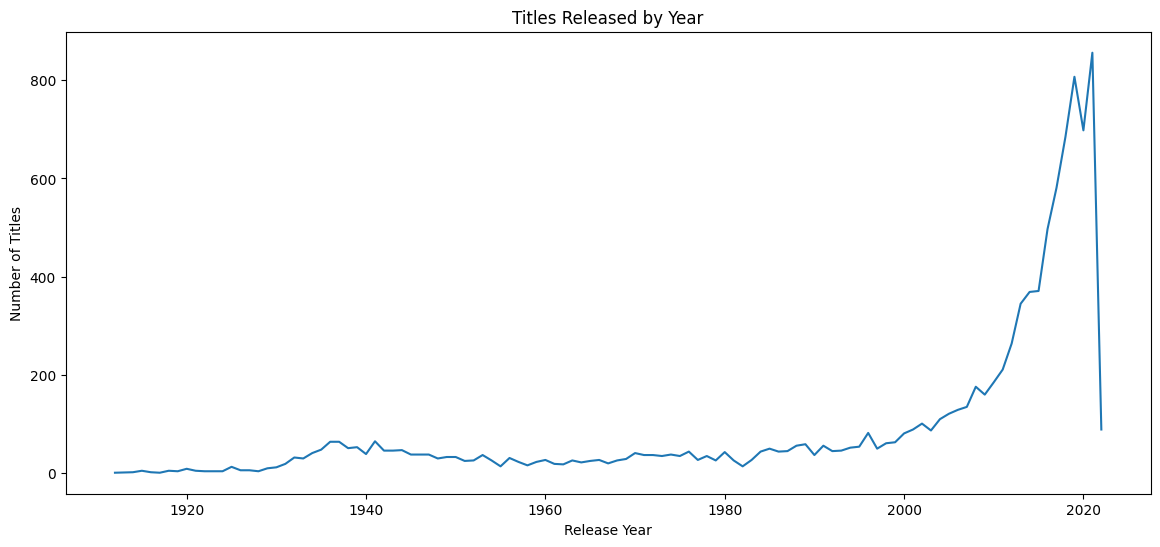

In [78]:
#Release year trend: Displays the yearly trend in content releases.
import matplotlib.pyplot as plt

# Plot yearly content releases

plt.figure(figsize=(14,6))

release_year_count.plot()

plt.title('Titles Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

In [79]:
#identify top 10 release years:
#Top 10 years with the highest number of releases
eda_df['release_year'].value_counts().head(10)


,count
release_year,
2021,856
2019,807
2020,698
2018,685
2017,581
2016,497
2015,371
2014,369
2013,345


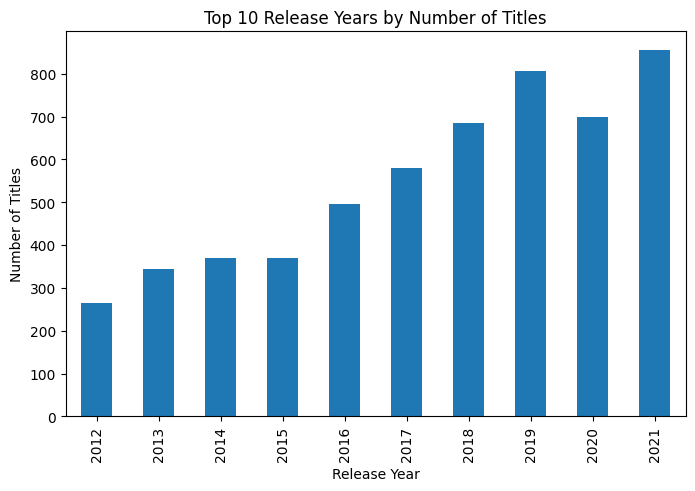

In [80]:
#visualize top 10 release years:
# Bar chart showing the years with the highest content releases.
top10_years = eda_df['release_year'].value_counts().head(10)

plt.figure(figsize=(8,5))

top10_years.sort_index().plot(kind='bar')

plt.title('Top 10 Release Years by Number of Titles')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

In [81]:
#Decade analysis:
# Counts the number of titles released in each decade.
eda_df['release_decade'].value_counts().sort_index()

,count
release_decade,
1910,20
1920,65
1930,414
1940,420
1950,254
1960,239
1970,355
1980,408
1990,546


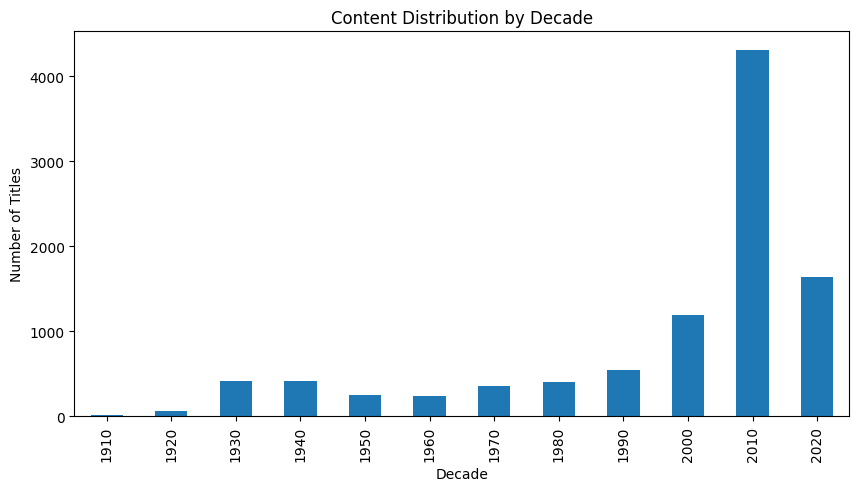

In [82]:
#Decade visualization:
# Displays the distribution of titles across different decades.
plt.figure(figsize=(10,5))

eda_df['release_decade'].value_counts().sort_index().plot(kind='bar')

plt.title('Content Distribution by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Titles')

plt.show()

**Business insights for second analysis release year:**

The release year analysis shows how the Amazon Prime catalogue has evolved over time. The platform includes titles spanning multiple decades, from classic productions to recent releases. The trend indicates a substantial increase in the number of titles in recent years, reflecting a growing emphasis on expanding the content library. Decade-wise analysis further highlights that the majority of available titles belong to the more recent decades.

**Analysis 3:** Runtime Analysis

Question:How long are Amazon prime titles?

**Interpretation of descriptive statistics:**

**COUNT:** Runtime information is available for all **9,868 Amazon Prime titles**, indicating that there are no missing values in the runtime column.

**MEAN:** The average runtime of Amazon Prime titles is approximately **85.98 minutes**.

**MINIMUM RUNTIME:** The shortest title has a runtime of **1 minute**.

**MAXIMUM RUNTIME:** The longest title has a runtime of **549 minutes**, which is unusually high compared with the average and may represent an outlier or special content format.

**STANDARD DEVIATION:** The runtime shows noticeable variation, indicating that Amazon Prime contains a mix of short, medium, and long-duration content.

**FIRST QUARTILE (25%):** One-quarter of the titles have a runtime of **65 minutes or less**.

**MEDIAN (50%):** The median runtime is **89 minutes**, meaning that half of the titles have a runtime of 89 minutes or less.

**THIRD QUARTILE (75%):** Three-quarters of the titles have a runtime of **102 minutes or less**, indicating that very long titles are relatively uncommon.


In [83]:
# Generates descriptive statistics for the runtime of Amazon Prime titles.
eda_df['runtime'].describe()

,runtime
count,9868.000000
mean,85.979124
std,33.515714
min,1.000000
25%,65.000000
50%,89.000000
75%,102.000000
max,549.000000


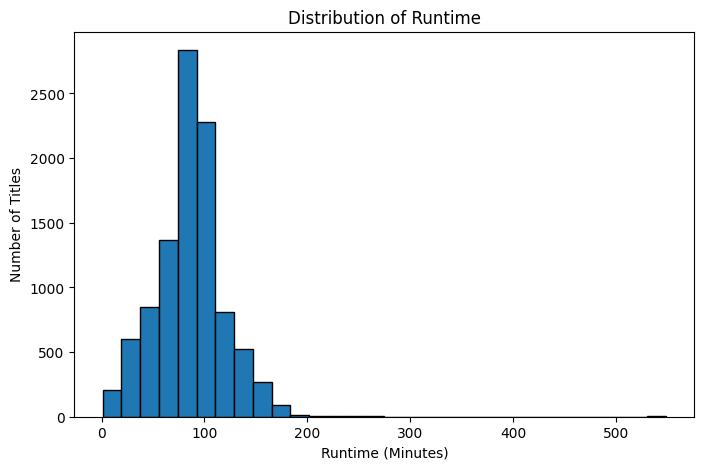

In [84]:
#Runtime Distribution (histogram):
# Displays the distribution of runtime across all Amazon Prime titles.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    eda_df['runtime'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Runtime')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Number of Titles')

plt.show()

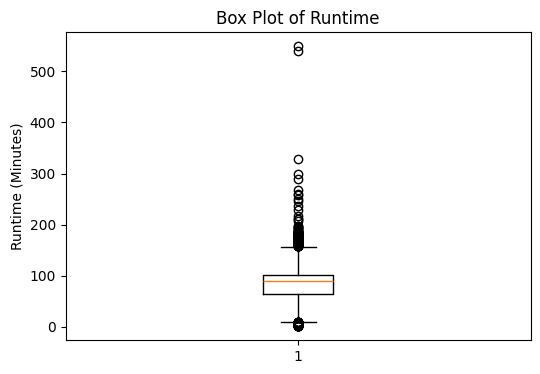

In [85]:
#Runtime boxplot:
#Identifies the spread of runtime values and detects potential outliers.
plt.figure(figsize=(6,4))

plt.boxplot(eda_df['runtime'])

plt.title('Box Plot of Runtime')
plt.ylabel('Runtime (Minutes)')

plt.show()

In [86]:
#Runtime Category Analysis:
#columns:
eda_df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'release_decade', 'runtime_category', 'content_age',
       'num_genres', 'num_production_countries'],
      dtype='object')

In [87]:
# Count titles in each runtime category
eda_df['runtime_category'].value_counts()

,count
runtime_category,
Medium,6526
Short,2176
Long,1166


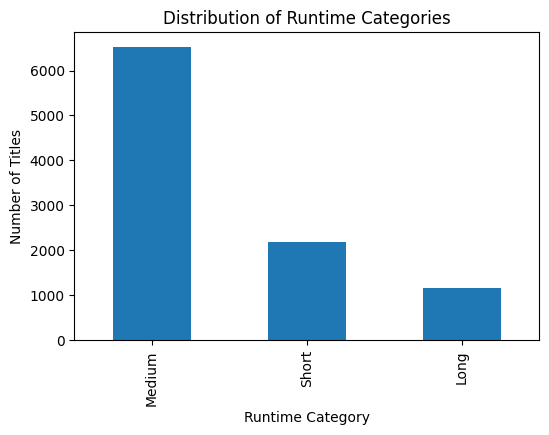

In [88]:
#Runtime Category Visualization:
# Visualizes the number of titles in each runtime category.
runtime_cat = eda_df['runtime_category'].value_counts()

plt.figure(figsize=(6,4))

runtime_cat.plot(kind='bar')

plt.title('Distribution of Runtime Categories')
plt.xlabel('Runtime Category')
plt.ylabel('Number of Titles')

plt.show()

**Business Interpretation of Runtime Analysis:**

Amazon Prime's catalog is primarily composed of medium-length titles, indicating a strong focus on standard movie-length content. Short-duration titles form a smaller portion of the library, while long-duration content is comparatively rare. This suggests that viewers are most commonly offered content with runtimes around the typical feature-film length.

**Analysis 4:** Genre Analysis

Question:What are the most common genres available on Amazon Prime?



In [89]:
# Displays the first 10 values of the genres column to understand its format.
eda_df['genres'].head(10)

,genres
0,"['comedy', 'family', 'animation', 'action', 'f..."
3,"['action', 'drama', 'war', 'western', 'comedy'..."
27,"['romance', 'war', 'drama']"
58,"['comedy', 'drama', 'romance']"
94,"['thriller', 'drama', 'romance']"
114,"['western', 'drama']"
178,"['drama', 'family', 'fantasy', 'romance', 'com..."
293,"['thriller', 'drama', 'crime']"
301,"['comedy', 'romance', 'drama']"
345,"['crime', 'drama']"


In [ ]:
# Ensure the genres column contains Python lists.
import ast

if isinstance(eda_df['genres'].iloc[0], str):
    eda_df['genres'] = eda_df['genres'].apply(ast.literal_eval)


In [91]:
# Counts how many times each genre appears across all titles and displays the top 10 genres.
from collections import Counter

# Count all genres
genre_counts = Counter()

from collections import Counter

genre_counts = Counter()

for genre_list in eda_df['genres']:
    genre_counts.update(genre_list)

import pandas as pd

genre_counts = pd.DataFrame(
    genre_counts.items(),
    columns=['Genre', 'Count']
)

genre_counts = genre_counts.sort_values(
    by='Count',
    ascending=False
)

genre_counts.head(10)

,Genre,Count
6,drama,4762
0,comedy,2987
11,thriller,2119
3,action,1820
10,romance,1751
12,crime,1250
16,documentation,1096
5,horror,1065
1,family,751
9,european,712


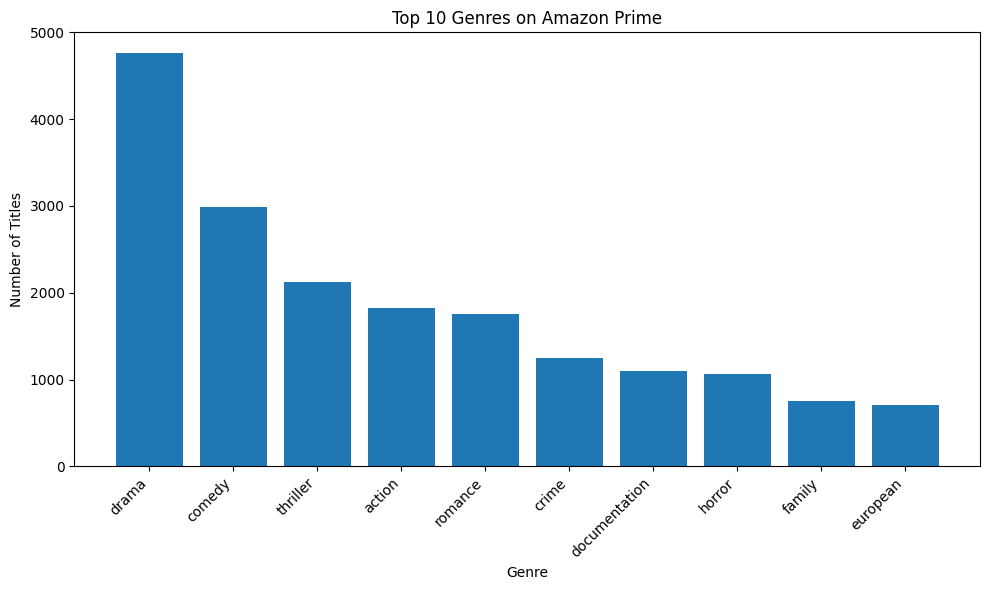

In [92]:
#Visualize top 10 Genres:
# Bar chart showing the ten most common genres available on Amazon Prime.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top10 = genre_counts.head(10)

plt.bar(
    top10['Genre'],
    top10['Count']
)

plt.title('Top 10 Genres on Amazon Prime')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [93]:
#calculate percentage distribution:
# Calculates the percentage share of each genre among all genre occurrences.
genre_counts['Percentage'] = (
    genre_counts['Count'] /
    genre_counts['Count'].sum()
) * 100

genre_counts.head(10)

,Genre,Count,Percentage
6,drama,4762,21.586582
0,comedy,2987,13.540345
11,thriller,2119,9.605621
3,action,1820,8.250227
10,romance,1751,7.937443
12,crime,1250,5.666364
16,documentation,1096,4.968268
5,horror,1065,4.827743
1,family,751,3.404352
9,european,712,3.227561


**Business Interpretation of genre analysis:**

Amazon Prime's content library is strongly centered around Drama and Comedy, suggesting a focus on storytelling and broad audience entertainment. The substantial presence of Thriller, Action, and Romance further indicates that the platform caters to viewers with varied preferences, offering a balanced mix of emotional, suspenseful, and action-oriented content.

**Analysis 5:** IMDb Score Distribution

Question:How are IMDb scores distributed among Amazon Prime titles?

In [94]:
#check missing values:
#Check for missing values in IMDb Score
eda_df['imdb_score'].isnull().sum()

np.int64(1021)

In [95]:
#Descriptive Statistics:
# Generates summary statistics such as mean, median, minimum, maximum, and quartiles for IMDb scores.
eda_df['imdb_score'].describe()

,imdb_score
count,8847.000000
mean,5.976534
std,1.344028
min,1.100000
25%,5.100000
50%,6.100000
75%,6.900000
max,9.900000


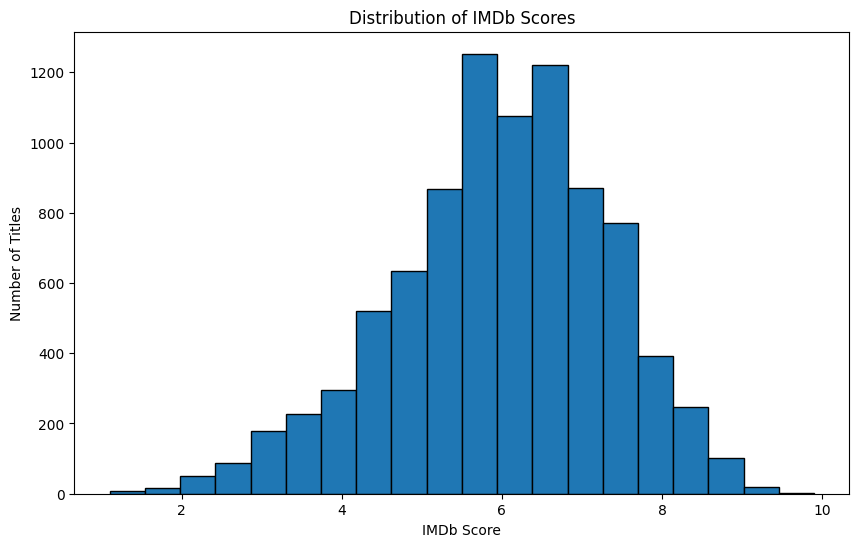

In [96]:
#Histograms:
# Histogram showing the distribution of IMDb scores.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    eda_df['imdb_score'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Number of Titles')

plt.show()

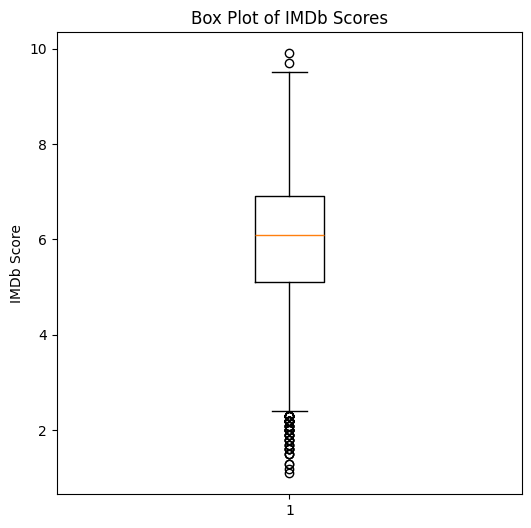

In [97]:
#Box plot:
# Box plot used to identify the spread of IMDb scores and detect potential outliers.
plt.figure(figsize=(6,6))

plt.boxplot(
    eda_df['imdb_score'].dropna()
)

plt.title('Box Plot of IMDb Scores')
plt.ylabel('IMDb Score')

plt.show()

In [98]:
#Rating Category Distribution:
# Categorizes IMDb scores into Poor, Average, Good, and Excellent quality groups.
def rating_category(score):

    if score < 5:
        return 'Poor'

    elif score < 7:
        return 'Average'

    elif score < 8.5:
        return 'Good'

    else:
        return 'Excellent'


eda_df['rating_category'] = eda_df['imdb_score'].apply(rating_category)

eda_df['rating_category'].value_counts()

,count
rating_category,
Average,4791
Good,2029
Poor,1854
Excellent,1194


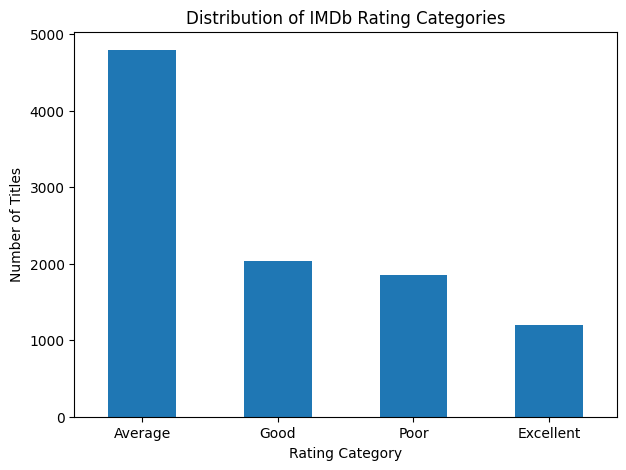

In [99]:
#Bar Chart:
# Bar chart showing the distribution of titles across IMDb rating categories.
plt.figure(figsize=(7,5))

eda_df['rating_category'].value_counts().plot(
    kind='bar'
)

plt.title('Distribution of IMDb Rating Categories')
plt.xlabel('Rating Category')
plt.ylabel('Number of Titles')

plt.xticks(rotation=0)

plt.show()

**Business Insights of IMDb Score Analysis:**

The IMDb rating analysis indicates that most Amazon Prime titles receive average audience ratings, with the highest concentration around a score of 6. While the platform includes many well-rated titles, only a relatively small portion achieves excellent ratings. This suggests that the catalog emphasizes breadth and variety rather than containing only critically acclaimed content.

**Analysis 6:** TMDb Score Analysis

Question: How are TMDb scores distributed among Amazon Prime titles?


In [100]:
#check missing values:
# Checks whether the TMDb score column contains any missing values.
eda_df['tmdb_score'].isnull().sum()

np.int64(2080)

In [101]:
#Descriptive Statastics:
# Generates summary statistics such as mean, median, minimum, maximum, and quartiles for TMDb scores.
eda_df['tmdb_score'].describe()

,tmdb_score
count,7788.000000
mean,5.984117
std,1.518040
min,0.800000
25%,5.100000
50%,6.000000
75%,6.900000
max,10.000000


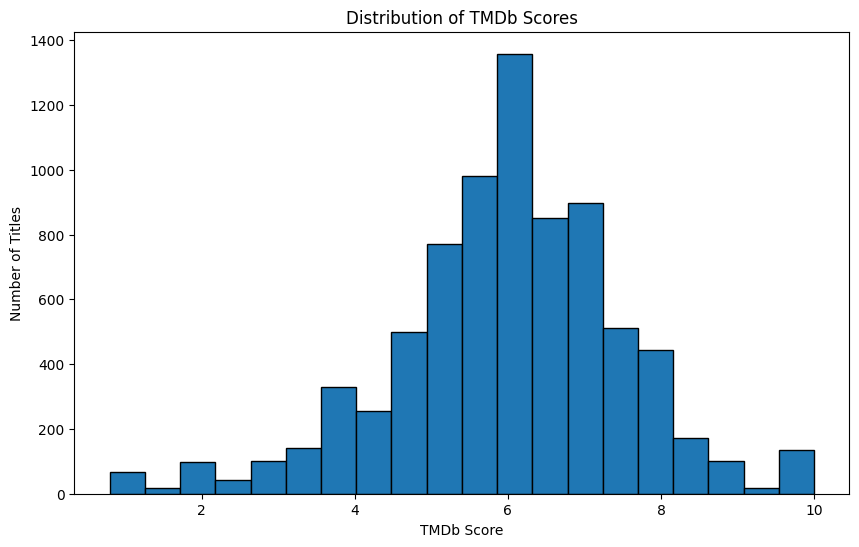

In [102]:
#Histogram:
# Histogram showing the distribution of TMDb scores.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    eda_df['tmdb_score'].dropna(),
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of TMDb Scores')
plt.xlabel('TMDb Score')
plt.ylabel('Number of Titles')

plt.show()

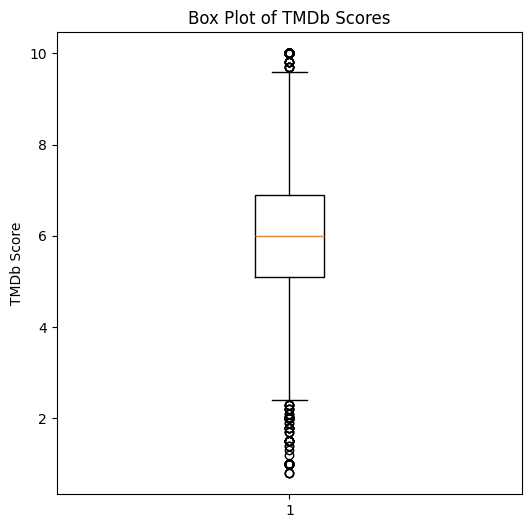

In [103]:
#Box Plot:
# Box plot used to identify the spread of TMDb scores and detect potential outliers.
plt.figure(figsize=(6,6))

plt.boxplot(
    eda_df['tmdb_score'].dropna()
)

plt.title('Box Plot of TMDb Scores')
plt.ylabel('TMDb Score')

plt.show()

In [104]:
#TMDb rating categories:
# Categorizes TMDb scores into Poor, Average, Good, and Excellent quality groups.
def tmdb_rating_category(score):

    if score < 5:
        return 'Poor'

    elif score < 7:
        return 'Average'

    elif score < 8.5:
        return 'Good'

    else:
        return 'Excellent'


eda_df['tmdb_rating_category'] = eda_df['tmdb_score'].apply(tmdb_rating_category)

eda_df['tmdb_rating_category'].value_counts()

,count
tmdb_rating_category,
Average,4297
Excellent,2401
Good,1624
Poor,1546


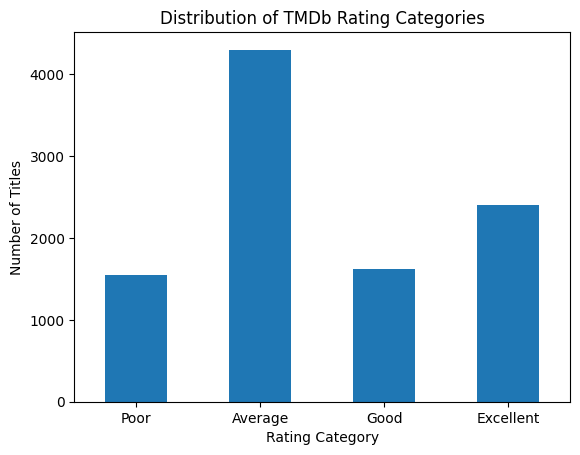

In [105]:
#Bar Chart:
# Bar chart showing the distribution of titles across TMDb rating categories.
import pandas as pd

rating_order = ['Poor', 'Average', 'Good', 'Excellent']

eda_df['tmdb_rating_category'] = pd.Categorical(
    eda_df['tmdb_rating_category'],
    categories=rating_order,
    ordered=True
)

eda_df['tmdb_rating_category'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribution of TMDb Rating Categories')
plt.xlabel('Rating Category')
plt.ylabel('Number of Titles')

plt.xticks(rotation=0)

plt.show()

**Business Insights of TMDb Score Analysis:**

The TMDb score analysis indicates that most Amazon Prime titles receive moderate community ratings, with scores concentrated around 6. While the majority of titles fall into the Average category, a considerable number achieve Excellent ratings, reflecting the presence of highly appreciated content alongside a broad catalog of moderately rated titles.

**Analysis 7:** Age Certification Analysis

Question: What is the distribution of age certifications among Amazon Prime titles?


In [106]:
#check missing values:
# Checks the number of missing values in the age certification column.
eda_df['age_certification'].isnull().sum()

np.int64(0)

In [107]:
#Count Age Certification:
# Counts the number of titles in each age certification category.
age_certification_count = eda_df['age_certification'].value_counts()

age_certification_count

,count
age_certification,
Unknown,6484
R,1249
PG-13,588
PG,582
G,269
TV-MA,217
TV-14,188
TV-PG,91
TV-Y,78


In [108]:
#Bar Chart:
# Bar chart showing the distribution of age certification categories.
(age_certification_count / age_certification_count.sum()) * 100

,count
age_certification,
Unknown,65.707337
R,12.657073
PG-13,5.958654
PG,5.897852
G,2.725983
TV-MA,2.199027
TV-14,1.905148
TV-PG,0.922173
TV-Y,0.790434


In [ ]:
# Calculate the percentage of titles whose age certification is recorded as Unknown.
unknown_percentage = (
    (eda_df['age_certification'] == 'Unknown').sum()
    / len(eda_df)
) * 100

print(f"Unknown Percentage: {unknown_percentage:.2f}%")


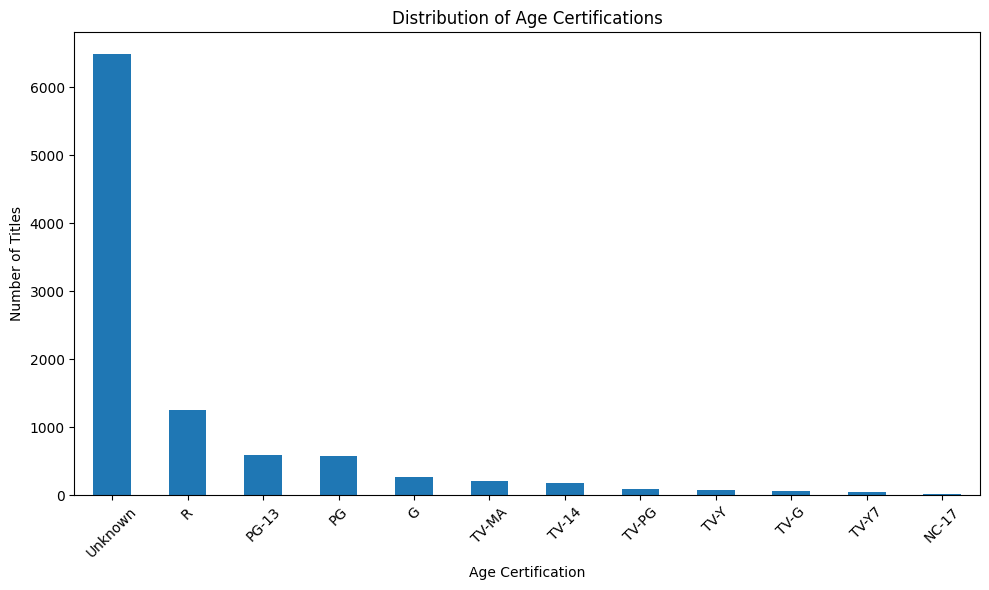

In [110]:
#Bar chart:
plt.figure(figsize=(10,6))

age_certification_count.plot(kind='bar')

plt.title('Distribution of Age Certifications')
plt.xlabel('Age Certification')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.tight_layout()


**Business Insights of Age Certification Analysis:**

The age certification analysis shows that **65.71%** of titles have an **Unknown** certification in the dataset. Among the known certifications, **R, PG-13, and PG** are the most common. The high proportion of Unknown values suggests that certification information is unavailable for a substantial part of the catalog, so certification-based audience targeting should account for this limitation.


**Univarite Analysis Summary:**

The univariate analysis explored the individual characteristics of Amazon Prime titles. The platform is predominantly composed of movies, with releases increasing significantly in recent years. Most titles have runtimes between 60 and 110 minutes, indicating a strong focus on standard feature-length content. Drama and Comedy are the most common genres, highlighting the platform's emphasis on story-driven and entertainment-focused content. Both IMDb and TMDb ratings are concentrated around 6, suggesting that most titles receive moderate audience ratings. Additionally, a large proportion of titles have Unknown age certifications due to unavailable certification information, while among the known certifications, R, PG-13, and PG are the most common. Overall, the univariate analysis provides a comprehensive understanding of the distribution and characteristics of the Amazon Prime content library.

#**Step 3: BIVARITE ANALYSIS:**

**Analysis 1:** Content Type Vs Runtime

Questions: Do Movies and TV Shows differ significantly in runtime?  

In [111]:
#checking missing values:
eda_df[['type', 'runtime']].isnull().sum()

,0
type,0
runtime,0


In [112]:
#Descriptive Statistics by content type:
eda_df.groupby('type')['runtime'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
MOVIE,8511.0,93.979556,28.053207,1.0,80.0,91.0,105.0,549.0
SHOW,1357.0,35.801032,17.702438,1.0,23.0,33.0,47.0,153.0


<Figure size 800x600 with 0 Axes>

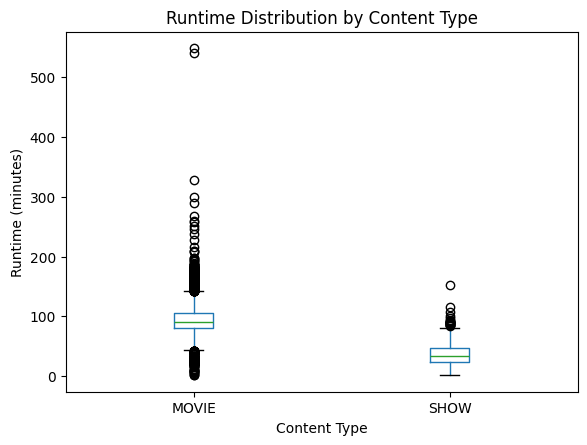

In [113]:
#Box Plot:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

eda_df.boxplot(
    column='runtime',
    by='type',
    grid=False
)

plt.title('Runtime Distribution by Content Type')
plt.suptitle('')  # Removes automatic title
plt.xlabel('Content Type')
plt.ylabel('Runtime (minutes)')

plt.show()

**Business Insights for content type vs runtime analysis:**

The analysis highlights distinct runtime patterns between Movies and TV Shows. Since Movies typically require a longer viewing commitment, Amazon Prime can recommend Movies to users seeking extended entertainment sessions, while recommending TV Shows to users who prefer shorter, episodic content. Understanding these differences can also support content acquisition strategies by maintaining a balanced catalog that caters to diverse viewing preferences.

**Analysis 2:** Content Type vs IMDb score

Questions: Do Movies or TV Shows receive higher audience ratings on Amazon Prime?

In [114]:
#Checking for missing values before analysis.
eda_df[['type', 'imdb_score']].isnull().sum()


,0
type,0
imdb_score,1021


In [115]:
#Handling missing values:
# Creating a new dataframe by removing rows with missing IMDb scores.
rating_df = eda_df.dropna(subset=['type', 'imdb_score'])

In [116]:
#verify missing values:
# Verifying that missing values have been removed successfully.
rating_df[['type', 'imdb_score']].isnull().sum()

,0
type,0
imdb_score,0


In [117]:
# Generating descriptive statistics for IMDb scores of Movies and TV Shows.
rating_df.groupby('type')['imdb_score'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
MOVIE,7681.0,5.803203,1.282753,1.1,5.0,5.9,6.7,9.9
SHOW,1166.0,7.118353,1.168788,1.3,6.5,7.3,7.9,9.7


<Figure size 800x600 with 0 Axes>

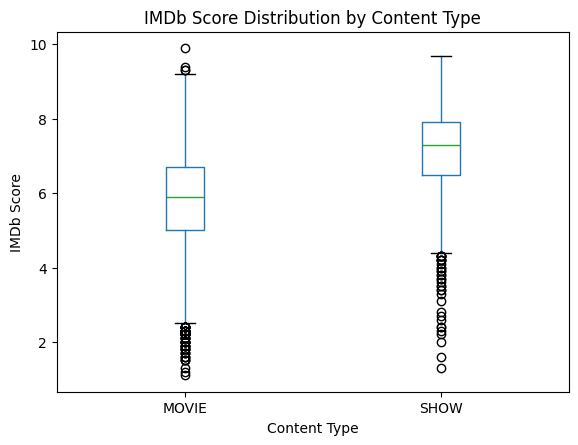

In [118]:
#create Box Plot:
# Creating a box plot to compare IMDb score distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

rating_df.boxplot(
    column='imdb_score',
    by='type',
    grid=False
)

plt.title('IMDb Score Distribution by Content Type')
plt.suptitle('')
plt.xlabel('Content Type')
plt.ylabel('IMDb Score')

plt.show()

**Business Insights for Content Type vs IMDb Score:**

The analysis shows that TV Shows have a higher average IMDb score than Movies in this dataset. This pattern can help Amazon Prime understand differences in audience ratings between content formats and can be considered alongside other factors when evaluating content acquisition, production, and engagement strategies.


**Analysis 3:** Genre vs IMDb Score Analysis

Questions: Which genres are most appreciated by viewers?

In [119]:
#check the datatypes of genres
# Checking whether the genres column is stored as a Python list or as a string. This determines whether it needs conversion before performing
# genre-wise analysis.
print(type(eda_df['genres'].iloc[0]))

<class 'list'>


In [120]:
# Displaying sample records to inspect how genres are stored for each title before preprocessing.
eda_df[['title','genres']].head(10)

,title,genres
0,The Three Stooges,"[comedy, family, animation, action, fantasy, h..."
3,The General,"[action, drama, war, western, comedy, european]"
27,The Best Years of Our Lives,"[romance, war, drama]"
58,His Girl Friday,"[comedy, drama, romance]"
94,In a Lonely Place,"[thriller, drama, romance]"
114,Stagecoach,"[western, drama]"
178,It's a Wonderful Life,"[drama, family, fantasy, romance, comedy]"
293,Detour,"[thriller, drama, crime]"
301,My Man Godfrey,"[comedy, romance, drama]"
345,Marihuana,"[crime, drama]"


In [121]:
# Splitting multiple genres into separate rows.
genre_df = eda_df[['genres','imdb_score']].explode('genres')

In [122]:
#checking missing values:
genre_df.isnull().sum()

,0
genres,209
imdb_score,1272


In [123]:
#remove missing values:
genre_df = genre_df.dropna(subset=['genres','imdb_score'])

In [124]:
# Calculating the average IMDb score for each genre
genre_rating = (
    genre_df.groupby('genres')['imdb_score']
    .mean()
    .sort_values(ascending=False)
)

In [125]:
# Displaying the top 15 highest-rated genres
genre_rating.head(15)

,imdb_score
genres,
documentation,6.994837
history,6.814248
reality,6.745736
animation,6.507143
sport,6.437500
war,6.396203
european,6.308023
music,6.202532
family,6.147652


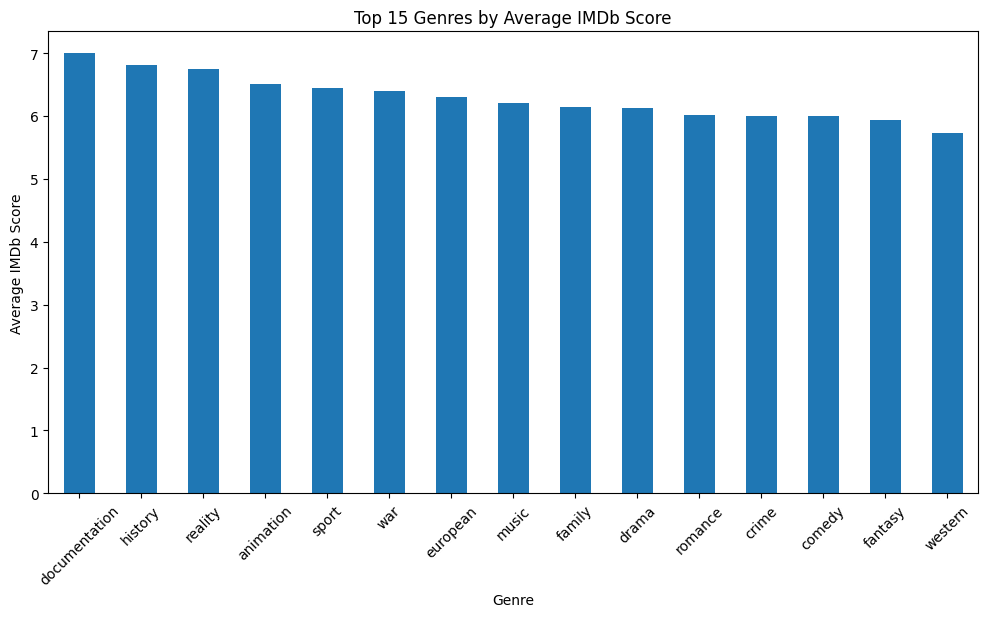

In [126]:
# Creating a bar chart to visualize the highest-rated genres.
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

genre_rating.head(15).plot(kind='bar')

plt.title('Top 15 Genres by Average IMDb Score')
plt.xlabel('Genre')
plt.ylabel('Average IMDb Score')

plt.xticks(rotation=45)

plt.show()

**Business Insights of Genre vs IMDb Score:**

The analysis indicates that informative and factual genres such as **Documentation** and **History** are among the higher-rated genres by average IMDb score in the analyzed dataset. These patterns can help identify genres that may receive stronger audience ratings and can be considered alongside other factors when evaluating content acquisition and production opportunities.


**Analysis 4:** Release Year vs IMDb Score

Question:Do newer titles receive better audience ratings than older titles?

In [127]:
#check missing values:
# Checking for missing values in release year and IMDb score.
eda_df[['release_year', 'imdb_score']].isnull().sum()

,0
release_year,0
imdb_score,1021


In [128]:
# Removing records with missing release year or IMDb score
year_rating = eda_df.dropna(subset=['release_year', 'imdb_score'])

In [129]:
# Calculating the average IMDb score for titles released
year_imdb = (
    year_rating
    .groupby('release_year')['imdb_score']
    .mean()
)

In [130]:
# Displaying the first few years and their corresponding
year_imdb.head(10)

,imdb_score
release_year,
1912,5.800000
1914,5.600000
1915,6.140000
1916,7.050000
1917,6.300000
1918,6.240000
1919,6.850000
1920,6.233333
1921,6.300000


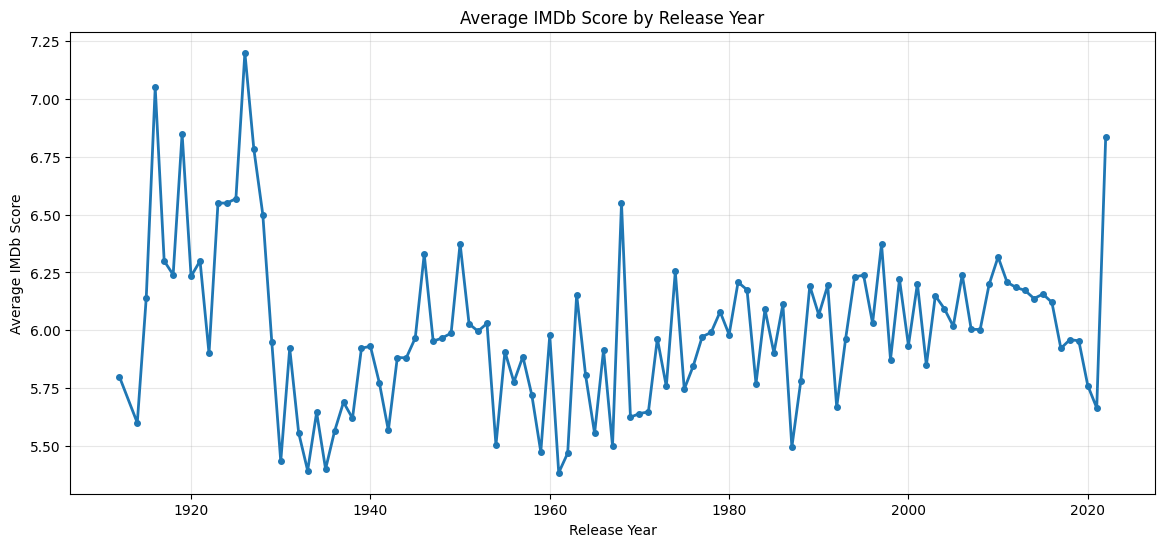

In [131]:
# Creating a line chart to visualize how average IMDb ratings have changed across release years.
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    year_imdb.index,
    year_imdb.values,
    marker='o',
    linewidth=2,
    markersize=4
)

plt.title('Average IMDb Score by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average IMDb Score')

plt.grid(alpha=0.3)

plt.show()

In [132]:
# Displaying the top 10 release years with the highest average IMDb ratings.
year_imdb.sort_values(ascending=False).head(10)

,imdb_score
release_year,
1926,7.200000
1916,7.050000
1919,6.850000
2022,6.836765
1927,6.783333
1925,6.569231
1968,6.550000
1924,6.550000
1923,6.550000


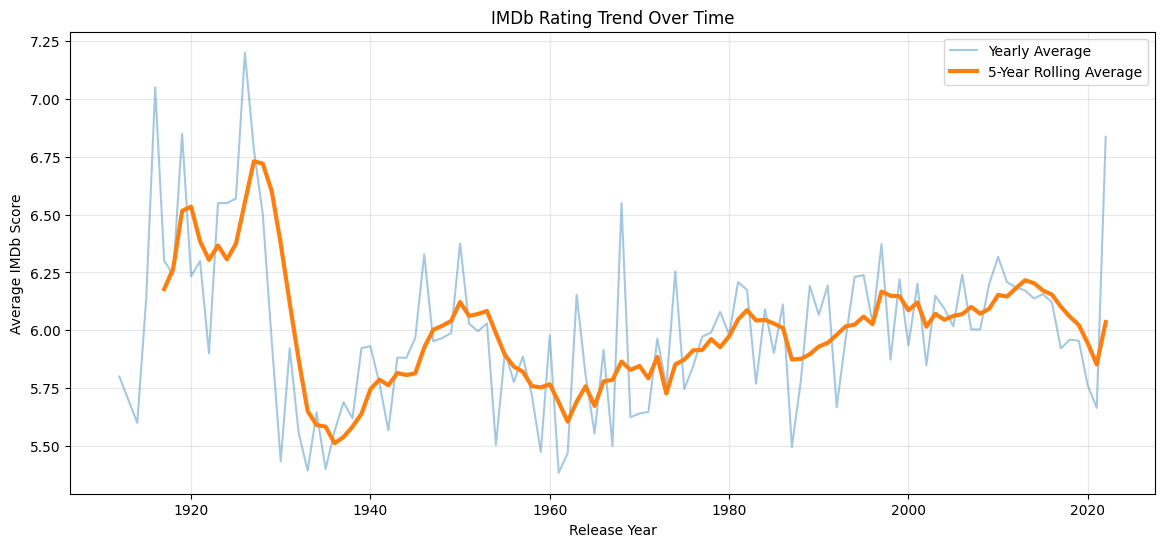

In [133]:
# Applying a 5-year rolling average to smooth yearly fluctuations and reveal the long-term trend in IMDb ratings.
rolling_imdb = year_imdb.rolling(window=5).mean()

plt.figure(figsize=(14,6))

plt.plot(year_imdb.index, year_imdb.values, alpha=0.4, label='Yearly Average')
plt.plot(rolling_imdb.index, rolling_imdb.values, linewidth=3, label='5-Year Rolling Average')

plt.title('IMDb Rating Trend Over Time')
plt.xlabel('Release Year')
plt.ylabel('Average IMDb Score')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**Business Insights of Release Year vs IMDb Score Analysis:**

The results show that average IMDb scores fluctuate across release years without a clear consistent upward or downward trend. Release year alone therefore does not appear to be a sufficient indicator of IMDb rating in this dataset. Content evaluation can consider quality and audience response alongside the age of the title.


# **Step 4: MULTIVARIATE ANALYSIS:**


**Analysis 1:** IMDb Score vs IMDb Votes vs Content Type

Question: Is there any relationship between IMDb ratings and the number of IMDb votes, and does this relationship differ between Movies and Shows?

In [134]:
#checking the required columns:
eda_df[['type', 'imdb_score', 'imdb_votes']].head()

,type,imdb_score,imdb_votes
0,SHOW,8.6,1092.0
3,MOVIE,8.2,89766.0
27,MOVIE,8.1,63026.0
58,MOVIE,7.8,57835.0
94,MOVIE,7.9,30924.0


In [135]:
#remove missing values:
imdb_data = eda_df[['type', 'imdb_score', 'imdb_votes']].dropna()

imdb_data.head()

,type,imdb_score,imdb_votes
0,SHOW,8.6,1092.0
3,MOVIE,8.2,89766.0
27,MOVIE,8.1,63026.0
58,MOVIE,7.8,57835.0
94,MOVIE,7.9,30924.0


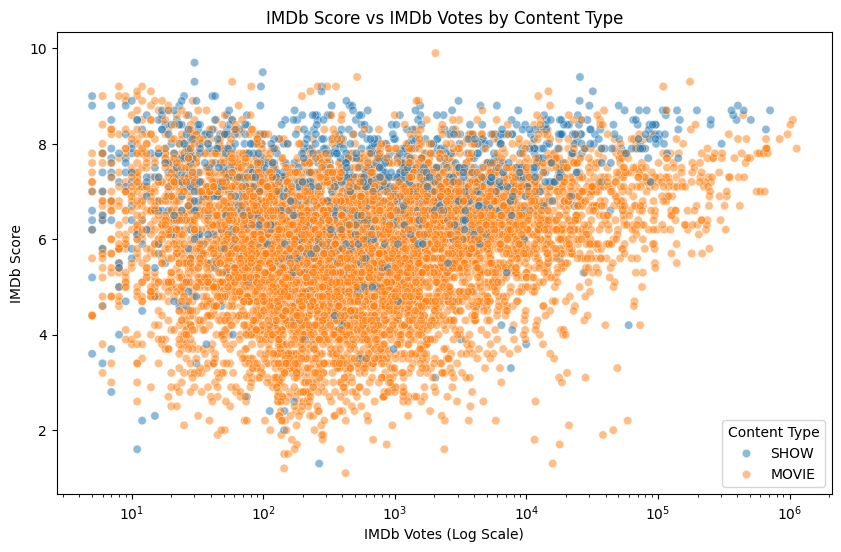

In [136]:
#creating multivarite scatter plot:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=imdb_data,
    x='imdb_votes',
    y='imdb_score',
    hue='type',
    alpha=0.5
)

plt.xscale('log')

plt.title('IMDb Score vs IMDb Votes by Content Type')
plt.xlabel('IMDb Votes (Log Scale)')
plt.ylabel('IMDb Score')
plt.legend(title='Content Type')
plt.show()

In [137]:
#adding correlation calculation:
imdb_data[['imdb_score', 'imdb_votes']].corr()

,imdb_score,imdb_votes
imdb_score,1.000000,0.165879
imdb_votes,0.165879,1.000000


**Business Insights of IMDb Score vs IMDb Votes vs Content Type in Multivariate Analysis:**

The correlation between IMDb Score and IMDb Votes is approximately **0.166**, indicating a weak positive relationship. IMDb voting activity and ratings therefore represent different aspects of content performance. Amazon Prime should consider both audience engagement and ratings rather than using vote count alone as an indicator of content quality.


**Analysis 2:** Runtime vs IMDb Score vs Content Type

Question: Does the relationship between content runtime and IMDb score differ between Movies and Shows?

In [138]:
#preparing the data:
runtime_data = eda_df[['type', 'runtime', 'imdb_score']].dropna()

runtime_data.head()


,type,runtime,imdb_score
0,SHOW,19,8.6
3,MOVIE,78,8.2
27,MOVIE,171,8.1
58,MOVIE,92,7.8
94,MOVIE,94,7.9


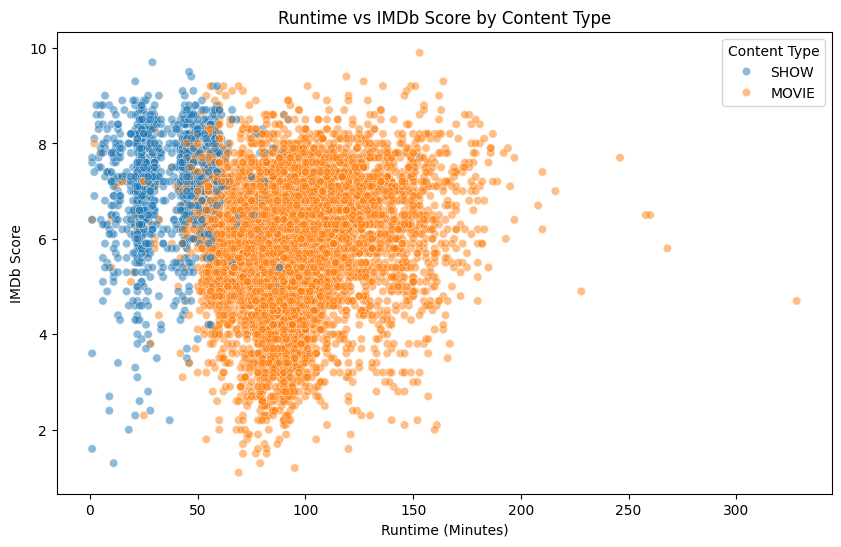

In [139]:
#creating multivarite graph:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=runtime_data,
    x='runtime',
    y='imdb_score',
    hue='type',
    alpha=0.5
)

plt.title('Runtime vs IMDb Score by Content Type')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('IMDb Score')
plt.legend(title='Content Type')
plt.show()

**Business insight of Runtime vs IMDb Score vs Content Type in multivariate analysis:**

Content length alone does not appear to be a strong indicator of IMDb ratings. Amazon Prime can therefore consider different runtime formats for Movies and Shows rather than assuming that longer or shorter content will automatically receive higher audience ratings.

**Analysis 3:** IMDb Score vs TMDB Popularity vs Content Type

Question:Is there a relationship between content ratings and popularity, and does the pattern differ between Movies and Shows?

---



In [140]:
#prepare for data:
popularity_data = eda_df[['type', 'imdb_score', 'tmdb_popularity']].dropna()

popularity_data.head()

,type,imdb_score,tmdb_popularity
0,SHOW,8.6,15.424
3,MOVIE,8.2,8.647
27,MOVIE,8.1,8.435
58,MOVIE,7.8,11.270
94,MOVIE,7.9,8.273


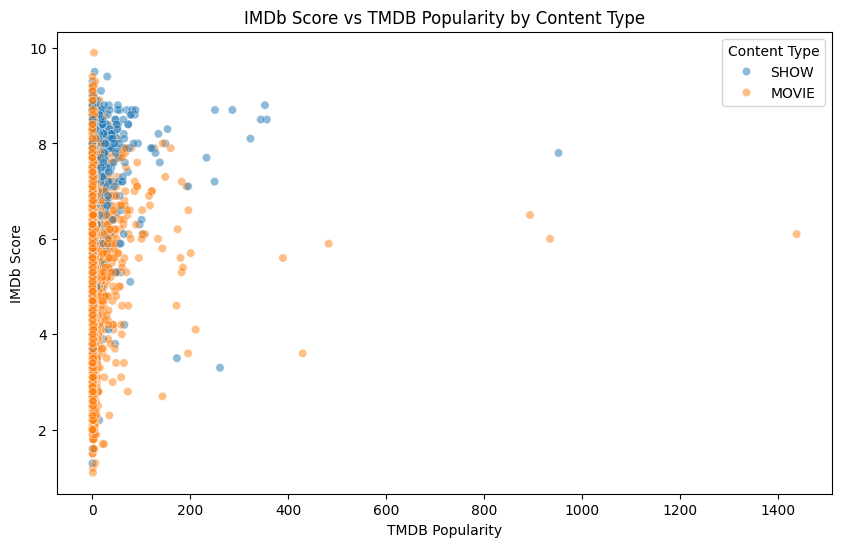

In [141]:
#creating a graph:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=popularity_data,
    x='tmdb_popularity',
    y='imdb_score',
    hue='type',
    alpha=0.5
)

plt.title('IMDb Score vs TMDB Popularity by Content Type')
plt.xlabel('TMDB Popularity')
plt.ylabel('IMDb Score')
plt.legend(title='Content Type')
plt.show()

**Business Insights of IMDb Score vs TMDB Popularity vs Content Type in multivariate analysis:**

Popularity and audience rating represent different aspects of content performance. A title with high popularity does not necessarily have a high IMDb rating. Therefore, content performance should be evaluated using multiple metrics such as popularity and ratings rather than relying on a single metric.

# **FINAL PROJECT SUMMARY AND KEY FINDINGS**


## **1. KEY FINDINGS:**

**A. Content Type Distribution:**

The dataset contains **9,868 unique titles** after duplicate handling.

* Movies: 8,511
* TV Shows: 1,357

Movies account for approximately **86.25%** of the catalog.

**Finding:** Amazon Prime's catalog in this dataset is predominantly composed of Movies.

**B. Runtime Analysis:**

* The average runtime is approximately **85.98 minutes**.
* The median runtime is **89 minutes**.
* Movies generally have longer runtimes than TV Shows.

**Finding:** Movies and TV Shows show distinct runtime patterns, reflecting their different viewing formats.

**C. IMDb Score Analysis:**

* The average IMDb score is approximately **5.98**.
* IMDb scores range from approximately **1.1 to 9.9**.
* TV Shows have a higher average IMDb score than Movies in this analysis.

**Finding:** TV Shows demonstrate higher IMDb ratings in this dataset.

**D. Genre vs IMDb Score:**

The analysis indicates that genres such as **Documentation and History** are among the higher-rated genres by average IMDb score.

**Finding:** Informative and factual genres perform strongly in terms of audience ratings in this analysis.

**E. Release Year vs IMDb Score:**

Average IMDb scores fluctuate across release years without a clear consistent upward or downward trend.

**Finding:** Release year alone does not appear to be a sufficient indicator of IMDb rating in this dataset.

**F. IMDb Score vs IMDb Votes:**

The correlation between IMDb Score and IMDb Votes is approximately **0.166**, indicating a weak positive relationship.

**Finding:** IMDb vote count and rating provide different perspectives on content performance.

**G. Runtime vs IMDb Score:**

The multivariate analysis does not show a strong direct relationship between runtime and IMDb score.

**Finding:** Longer content does not necessarily receive higher IMDb ratings.

**H. IMDb Score vs TMDB Popularity:**

The analysis does not show a strong direct relationship between TMDB popularity and IMDb score.

**Finding:** Popularity and audience rating represent different aspects of content performance.


## **2. OVERALL BUSINESS INSIGHTS:**

**A. Balanced Content Strategy:**

Since Movies dominate the catalog while TV Shows represent a smaller portion, understanding the different viewing patterns of both formats can help maintain a catalog that caters to diverse viewing preferences.

**B. Content Quality Over Runtime:**

Since runtime does not show a strong direct relationship with IMDb ratings, content length alone should not be treated as an indicator of audience satisfaction.

**C. High-Rated Genre Patterns:**

Genres such as Documentation and History show strong IMDb ratings in this analysis. These patterns can help identify genres that may deserve further attention in content acquisition and production strategies.

**D. Quality Across Different Release Periods:**

Since release year does not show a clear consistent relationship with IMDb scores, both classic and modern content can be considered based on quality and audience response rather than age alone.

**E. Use Multiple Performance Metrics:**

IMDb ratings, IMDb votes, and TMDB popularity provide different perspectives on content performance. Evaluating multiple metrics together can provide a more complete understanding than relying on a single metric.


## **FINAL PROJECT CONCLUSION:**

The Exploratory Data Analysis of the Amazon Prime Movies and TV Shows dataset provided insights into the platform's content distribution, runtime, ratings, genres, and popularity. The analysis found that Movies form the majority of the catalog, while TV Shows represent a smaller but distinct content category with different runtime and rating patterns.

Genre analysis indicated that informative and factual genres such as Documentation and History were among the higher-rated genres by average IMDb score in the analyzed dataset. The analysis of release year showed fluctuations in average IMDb scores without a clear consistent trend, suggesting that release year alone is not a sufficient indicator of audience ratings.

The multivariate analysis showed that runtime and TMDB popularity do not display strong direct relationships with IMDb scores, while IMDb votes show only a weak positive relationship with IMDb scores. This highlights the importance of considering multiple factors when evaluating content performance.

Overall, the analysis provides a data-driven understanding of the Amazon Prime content library and can support decisions related to content selection, acquisition, production, and audience engagement.
